# Loan default EDA: five business questions

**Setting:** Home Credit **application_train** — predict whether the current contract **defaults** (`TARGET = 1`).

**How to read this notebook:** Each numbered section asks one question; SQL lives in `sql/eda/`. Plots emphasize **default rate vs. portfolio baseline**, **volume** (`n`), and **concentration** where it helps. Features for modeling are under `sql/features/` — use proper splits and leakage checks before production.

**Sections:** (1) occupation and where defaults concentrate, (2) payment burden, (3) income × credit, (4) bureau and external scores, (5) age.


In [39]:
from __future__ import annotations

from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
SQL_EDA = REPO_ROOT / "sql" / "eda"
DB_PATH = REPO_ROOT / "data" / "home_credit.db"

con = duckdb.connect(str(DB_PATH), read_only=True)

%matplotlib inline
plt.style.use("ggplot")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

In [40]:
def run_sql_file(name: str) -> pd.DataFrame:
    path = SQL_EDA / name
    if not path.is_file():
        raise FileNotFoundError(path)
    return con.sql(path.read_text()).df()


def lower_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).lower() for c in out.columns]
    return out


def peek(df: pd.DataFrame, n: int = 5) -> None:
    display(df.head(n))


def wilson_ci(k: np.ndarray | float, n: np.ndarray | float, z: float = 1.96):
    # Wilson score interval for binomial proportion; k=successes, n=trials.
    k, n = np.asarray(k, dtype=float), np.asarray(n, dtype=float)
    p = np.where(n > 0, k / n, np.nan)
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = (
        z * np.sqrt(np.clip(p * (1 - p) / n + z**2 / (4 * n**2), 0, np.inf)) / denom
    )
    return np.clip(center - margin, 0, 1), np.clip(center + margin, 0, 1)


BASELINE_PCT: float | None = None

In [41]:
# --- Portfolio baseline (reference line in plots; table only here)
td = lower_columns(run_sql_file("target_distribution.sql"))
peek(td)
pos = td[td["target"] == 1]["pct"].astype(float)
BASELINE_PCT = float(pos.iloc[0]) if len(pos) else float(td["pct"].iloc[-1])
print(f"Portfolio default rate (train): {BASELINE_PCT:.2f}%")

,target,n,pct
0,0,282686,91.927118
1,1,24825,8.072882


Portfolio default rate (train): 8.07%


---

## 1. Does occupation line up with risk — and are defaults concentrated in a few job types?

**Question:** Do some occupations show clearly higher default rates (with enough volume to matter)? If we order jobs from **highest** to **lowest** default rate, how fast do we accumulate **people** versus **defaults**?

**Plots:** (a) Default rate by occupation vs portfolio baseline, with `n` labels. (b) **Concentration curve**: cumulative % of applicants vs cumulative % of all defaults along that ordering (like a Lorenz readout for job groups).

**How the data answers:** Wide spread in the bar chart shows **segmentation by job**; a concentration curve that rises **above** the diagonal means a **disproportionate share of defaults** sits in the riskiest occupations early in the ordering.


,occupation_type,n,n_default,default_rate_pct
0,Low-skill Laborers,2093,359.0,17.152413
1,Drivers,18603,2107.0,11.326130
2,Waiters/barmen staff,1348,152.0,11.275964
3,Security staff,6721,722.0,10.742449
4,Laborers,55186,5838.0,10.578770


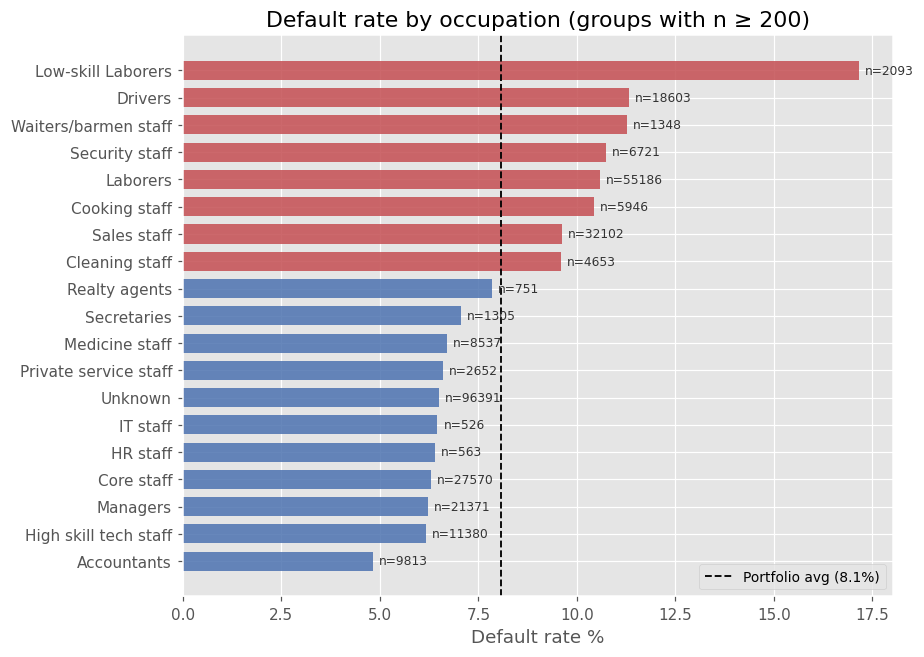

In [42]:
occ = lower_columns(run_sql_file("occupational_risk.sql"))
peek(occ)
floor = 200
occ_f = occ[occ["n"] >= floor].copy()
occ_f = occ_f.sort_values("default_rate_pct", ascending=True)

fig, ax = plt.subplots(figsize=(8.5, max(4.0, 0.32 * len(occ_f))))
y = np.arange(len(occ_f))
colors = np.where(occ_f["default_rate_pct"] > BASELINE_PCT, "#c44e52", "#4c72b0")
ax.barh(y, occ_f["default_rate_pct"], color=colors, alpha=0.85, height=0.7)
ax.axvline(
    BASELINE_PCT,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Portfolio avg ({BASELINE_PCT:.1f}%)",
)
ax.set_yticks(y)
ax.set_yticklabels(occ_f["occupation_type"])
ax.set_xlabel("Default rate %")
ax.set_title(f"Default rate by occupation (groups with n ≥ {floor})")
ax.legend(loc="lower right", fontsize=9)
for i, (_, row) in enumerate(occ_f.iterrows()):
    ax.text(
        row["default_rate_pct"] + 0.15,
        i,
        f"n={int(row['n'])}",
        va="center",
        fontsize=8,
        color="#333",
    )
fig.tight_layout()

,occupation_type,n,n_default,default_rate_pct,cum_pop_pct_worst_first,cum_default_pct_worst_first
0,Low-skill Laborers,2093,359.0,17.152413,0.680626,1.446123
1,Drivers,18603,2107.0,11.326130,6.730166,9.933535
2,Waiters/barmen staff,1348,152.0,11.275964,7.168524,10.545821
3,Security staff,6721,722.0,10.742449,9.354137,13.454179
4,Laborers,55186,5838.0,10.578770,27.300162,36.970796


,occupation_type,n,n_default,default_rate_pct,cum_pop_pct_worst_first,cum_default_pct_worst_first
16,Managers,21371,1328.0,6.214028,93.108214,95.266868
17,High skill tech staff,11380,701.0,6.159930,96.808895,98.090634
18,Accountants,9813,474.0,4.830327,100.000000,100.000000


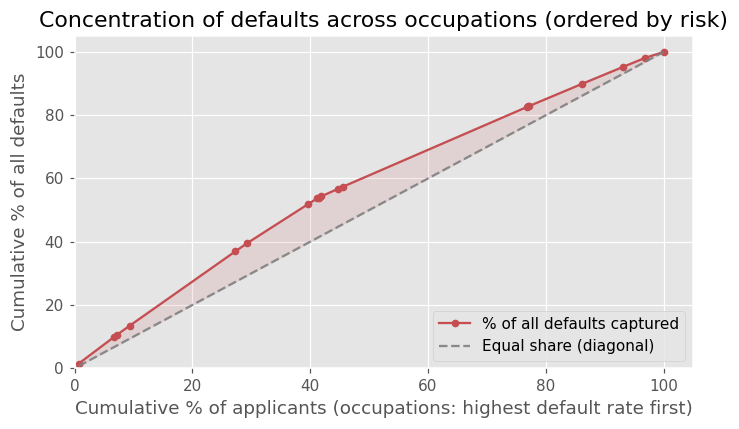

In [43]:
occ_c = lower_columns(run_sql_file("risk_concentration_by_occupation.sql"))
display(occ_c.head(5))
display(occ_c.tail(3))
fig, ax = plt.subplots(figsize=(6.5, 4.0))
ax.plot(
    occ_c["cum_pop_pct_worst_first"],
    occ_c["cum_default_pct_worst_first"],
    marker="o",
    markersize=4,
    label="% of all defaults captured",
    color="#c44e52",
)
ax.plot(
    occ_c["cum_pop_pct_worst_first"],
    occ_c["cum_pop_pct_worst_first"],
    linestyle="--",
    color="gray",
    alpha=0.9,
    label="Equal share (diagonal)",
)
ax.fill_between(
    occ_c["cum_pop_pct_worst_first"],
    occ_c["cum_pop_pct_worst_first"],
    occ_c["cum_default_pct_worst_first"],
    alpha=0.12,
    color="#c44e52",
)
ax.set_xlabel("Cumulative % of applicants (occupations: highest default rate first)")
ax.set_ylabel("Cumulative % of all defaults")
ax.set_title("Concentration of defaults across occupations (ordered by risk)")
ax.legend(loc="lower right")
ax.set_xlim(0, 105)
ax.set_ylim(0, 105)
fig.tight_layout()

**Conclusion:** Occupation is a strong predictor of default rate and a simple feature to use with 12 unique values.


---

## 2. Is payment burden (affordability) a clear driver?

**Question:** Do applicants with **higher monthly installment relative to income** default more often?

**Plot:** Default rate by **annuity/income decile** with baseline and Wilson band (single panel).

**How the data answers:** A rising curve with intervals above the baseline in high deciles supports **cashflow stress** as a core narrative.

**Note:** Volume is similar across deciles (equal-sized bins), so the plot focuses on the rate pattern and uncertainty.


,decile,n,n_default,default_rate_pct
0,1,30750,2168.0,7.050407
1,2,30750,2258.0,7.343089
2,3,30750,2404.0,7.817886
3,4,30750,2413.0,7.847154
4,5,30750,2422.0,7.876423


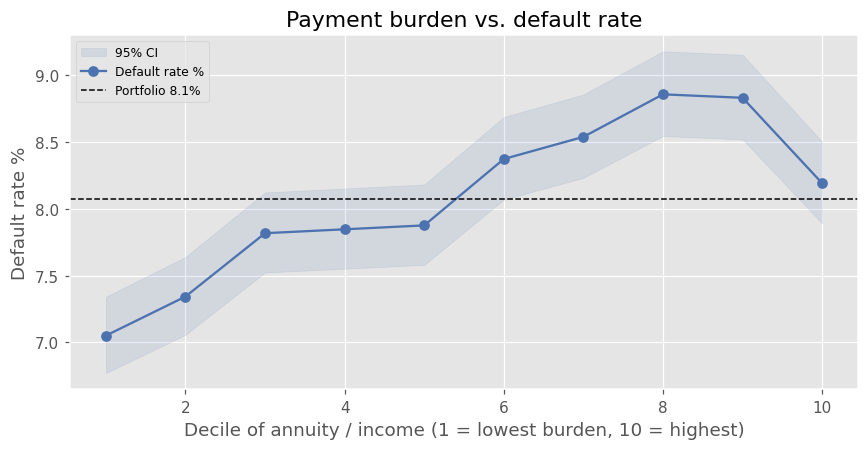

In [44]:
burden = lower_columns(run_sql_file("annuity_to_income_risk.sql"))
peek(burden)
k, n = burden["n_default"].values, burden["n"].values
lo, hi = wilson_ci(k, n)
lo_pct, hi_pct = 100 * lo, 100 * hi
x = burden["decile"].values

fig, ax1 = plt.subplots(figsize=(8, 4.2))
ax1.fill_between(x, lo_pct, hi_pct, alpha=0.12, color="#4c72b0", label="95% CI")
ax1.plot(
    x, burden["default_rate_pct"], marker="o", color="#4c72b0", label="Default rate %"
)
ax1.axhline(
    BASELINE_PCT,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Portfolio {BASELINE_PCT:.1f}%",
)
ax1.set_xlabel("Decile of annuity / income (1 = lowest burden, 10 = highest)")
ax1.set_ylabel("Default rate %")
ax1.set_title("Payment burden vs. default rate")
ax1.legend(loc="upper left", fontsize=8)
fig.tight_layout()

**Conclusion:** Higher payment burdens lead to higher default rates. Individuals in the lower median of payment burden are less likely to default. The single exception is the 10th decile, where a significant drop is seen from the 9th decile.


---

## 3. Credit size vs. income — leverage beyond income?

**Question:** Does **requested credit** matter **beyond** income?

**Plot:** **Heatmap** of default rate on (income decile × credit decile).

**How the data answers:** Hot corners in **high credit × low income** indicate **leverage** matters; a vertical or horizontal pattern would say one dimension dominates.

**Note:** Cell colors are scaled to the min/max default rate in this grid so differences show up clearly.


,income_decile,credit_decile,n,n_default,default_rate_pct
0,1,1,8677,529.0,6.096577
1,1,2,5626,423.0,7.518663
2,1,3,4019,345.0,8.584225
3,1,4,3322,389.0,11.709813
4,1,5,2312,220.0,9.515571


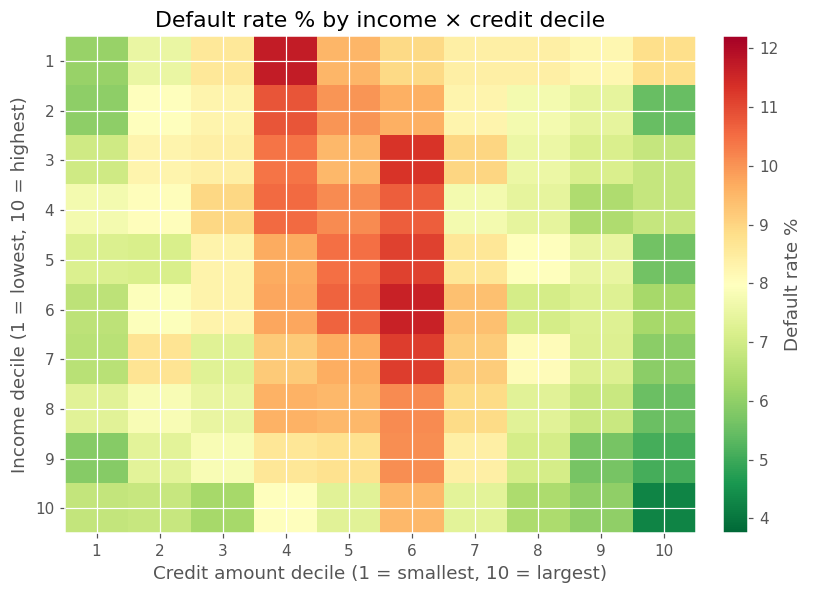

In [45]:
heat = lower_columns(run_sql_file("income_credit_default_heatmap.sql"))
peek(heat)
pivot = heat.pivot(
    index="income_decile", columns="credit_decile", values="default_rate_pct"
)
v = pivot.values
vmin, vmax = float(np.nanmin(v)), float(np.nanmax(v))
pad = max(0.5, (vmax - vmin) * 0.05)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
im = ax.imshow(v, aspect="auto", cmap="RdYlGn_r", vmin=vmin - pad, vmax=vmax + pad)
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(10))
ax.set_xticklabels(np.arange(1, 11))
ax.set_yticklabels(np.arange(1, 11))
ax.set_xlabel("Credit amount decile (1 = smallest, 10 = largest)")
ax.set_ylabel("Income decile (1 = lowest, 10 = highest)")
ax.set_title("Default rate % by income × credit decile")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label("Default rate %")
fig.tight_layout()

**Conclusion:** The safest applicants tend to be on the edges of the credit amount distributions, with the highest risk applicants in the middle. Additionally, the lower the income, the larger the risk-band and the higher the default rate.


---

## 4. Bureau history and external scores

**Question:** Do **thin files** (no bureau rows) and **normalized external scores** line up with default?

**Plots:** Bureau depth deciles; **no bureau vs. has bureau**; **box plots** with a light point strip.

**How the data answers:** Higher default on thin files or lower scores supports bureau investment; overlap shows why models need more than one signal.

**Note:** Bureau depth is a coarse proxy for “how much history we see,” not credit quality by itself.


,decile,n,n_default,default_rate_pct
0,1,30752,3116.0,10.132674
1,2,30751,2844.0,9.248480
2,3,30751,2572.0,8.363956
3,4,30751,2335.0,7.593249
4,5,30751,2320.0,7.544470


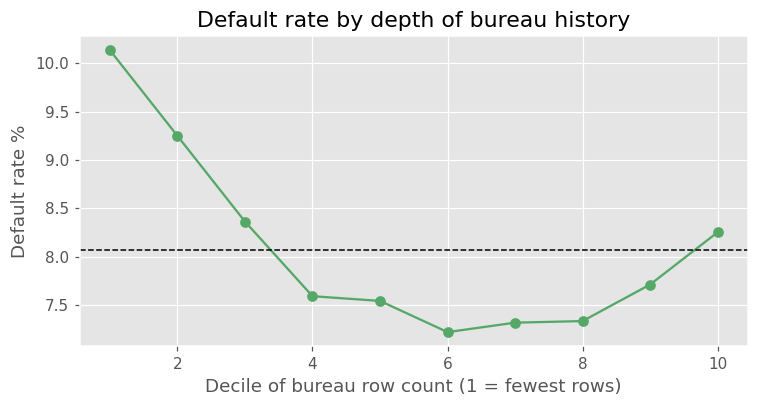

In [46]:
depth = lower_columns(run_sql_file("bureau_depth_risk.sql"))
peek(depth)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(depth["decile"], depth["default_rate_pct"], marker="o", color="#55a868")
ax.axhline(BASELINE_PCT, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Decile of bureau row count (1 = fewest rows)")
ax.set_ylabel("Default rate %")
ax.set_title("Default rate by depth of bureau history")
fig.tight_layout()

,segment,n,n_default,default_rate_pct
0,Has bureau history,263491,20368.0,7.730055
1,No bureau records,44020,4457.0,10.124943


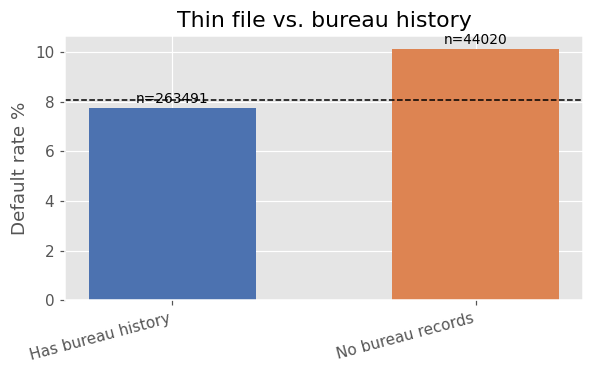

In [47]:
b0 = lower_columns(run_sql_file("bureau_zero_vs_rest.sql"))
peek(b0)
fig, ax = plt.subplots(figsize=(5.5, 3.5))
x = np.arange(len(b0))
colors_b = ["#dd8452" if "No bureau" in str(s) else "#4c72b0" for s in b0["segment"]]
ax.bar(x, b0["default_rate_pct"], color=colors_b, width=0.55)
ax.axhline(BASELINE_PCT, color="black", linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(b0["segment"], rotation=15, ha="right")
ax.set_ylabel("Default rate %")
ax.set_title("Thin file vs. bureau history")
for i, row in b0.iterrows():
    ax.text(
        i, row["default_rate_pct"] + 0.2, f"n={int(row['n'])}", ha="center", fontsize=9
    )
fig.tight_layout()

,target,avg_ext_source_1,avg_ext_source_2,avg_ext_source_3
0,0,0.511461,0.523479,0.520969
1,1,0.386968,0.410935,0.390717


/var/folders/gs/4q6p3s6s3bj8xrzv8tnmvx3c0000gn/T/ipykernel_93616/907403649.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["No default", "Default"], patch_artist=True, widths=0.5)
/var/folders/gs/4q6p3s6s3bj8xrzv8tnmvx3c0000gn/T/ipykernel_93616/907403649.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["No default", "Default"], patch_artist=True, widths=0.5)
/var/folders/gs/4q6p3s6s3bj8xrzv8tnmvx3c0000gn/T/ipykernel_93616/907403649.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["No default", "Default"], patch_artis

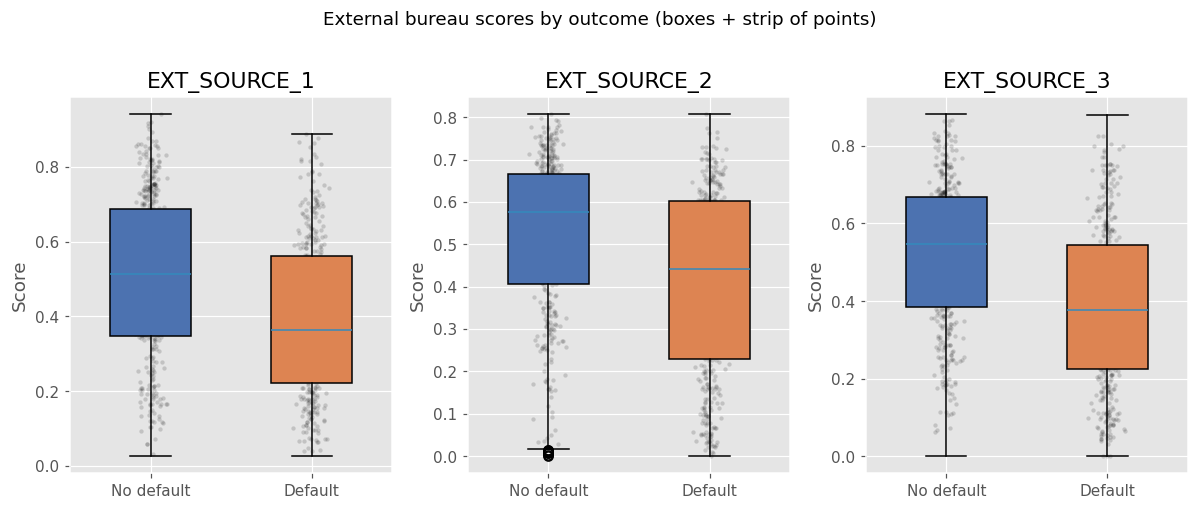

In [48]:
means = lower_columns(run_sql_file("external_scores_by_target.sql"))
peek(means)

q = (
    "SELECT target, ext_source_1, ext_source_2, ext_source_3 "
    "FROM application_train WHERE ext_source_1 IS NOT NULL "
    "OR ext_source_2 IS NOT NULL OR ext_source_3 IS NOT NULL"
)
raw = lower_columns(con.sql(q).df())

rng = np.random.default_rng(42)
sample_n = 2500
parts = []
for t in (0, 1):
    sub = raw[raw["target"] == t]
    if len(sub) > sample_n:
        sub = sub.sample(sample_n, random_state=42)
    parts.append(sub)
sampled = pd.concat(parts, ignore_index=True)

score_cols = ["ext_source_1", "ext_source_2", "ext_source_3"]
labels = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
fig, axes = plt.subplots(1, 3, figsize=(11, 4.5), sharey=False)
for ax, col, lab in zip(axes, score_cols, labels):
    s0 = sampled.loc[sampled["target"] == 0, col].dropna()
    s1 = sampled.loc[sampled["target"] == 1, col].dropna()
    data = [s0, s1]
    bp = ax.boxplot(
        data, labels=["No default", "Default"], patch_artist=True, widths=0.5
    )
    bp["boxes"][0].set_facecolor("#4c72b0")
    bp["boxes"][1].set_facecolor("#dd8452")
    for t, series in enumerate([s0, s1]):
        idx = rng.choice(len(series), size=min(400, len(series)), replace=False)
        y = series.iloc[idx].values
        xjit = rng.normal(t + 1, 0.04, size=len(y))
        ax.scatter(xjit, y, alpha=0.15, s=8, color="black", linewidths=0)
    ax.set_title(lab)
    ax.set_ylabel("Score")
fig.suptitle("External bureau scores by outcome (boxes + strip of points)", y=1.02)
fig.tight_layout()


**Conclusion:** more information about applications leads to significantly better predictions. Applicants with no bureau history, or very few few lines on record are more likely to default. Additionally, the available external signals show provide signal on default rate.


---

## 5. How does age relate to default risk?

**Question:** How does default rate move with **age** in **interpretable year bands**?

**Plot:** Age-band curve with **95% Wilson intervals** and `n` per band.

**How the data answers:** Compare each band to the **portfolio baseline** and watch whether the pattern is monotonic or has a mid-life dip—`n` labels show where estimates are most reliable.

**Note:** Quartile-by-age was dropped; bands give a clearer story than four rank buckets.


,age_band,sort_key,n,n_default,default_rate_pct
0,Under 25,1,12233,1504.0,12.294613
1,25–29,2,32953,3667.0,11.127970
2,30–34,3,39476,4054.0,10.269531
3,35–39,4,42855,3843.0,8.967448
4,40–44,5,41406,3242.0,7.829783


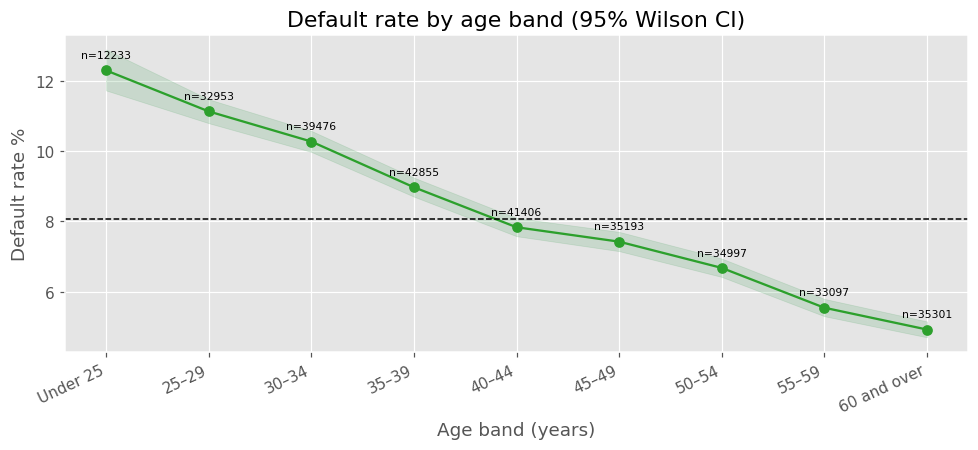

In [49]:
age_b = lower_columns(run_sql_file("age_risk_bands.sql"))
peek(age_b)
fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(age_b))
lo, hi = wilson_ci(age_b["n_default"].values, age_b["n"].values)
ax.fill_between(x, 100 * lo, 100 * hi, alpha=0.2, color="#55a868")
ax.plot(x, age_b["default_rate_pct"], marker="o", color="#2ca02c")
ax.axhline(BASELINE_PCT, color="black", linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(age_b["age_band"], rotation=25, ha="right")
ax.set_ylabel("Default rate %")
ax.set_xlabel("Age band (years)")
ax.set_title("Default rate by age band (95% Wilson CI)")
for xi, (_, row) in enumerate(age_b.iterrows()):
    ax.text(
        xi,
        row["default_rate_pct"] + 0.35,
        f"n={int(row['n'])}",
        ha="center",
        fontsize=7,
    )
fig.tight_layout()

**Conclusion:** older applicants are monotonically safer and less likely to default. The high risk segment is concentrated with younger applicants.


---

### Closing

This notebook covered **occupation** (levels + concentration curve), **affordability**, **income × credit**, **bureau + external scores**, and **age**. Next: leakage checks, proper splits, and features under `sql/features/`.
